<a href="https://colab.research.google.com/github/Edson-Felix/Pos-Puc/blob/main/MVP_Pos_Puc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Edson Felix de Souza Machado

**Matrícula:** 4052026000113

**Dataset:** [Vendas de derivados de petróleo e biocombustíveis](https://dados.gov.br/dados/conjuntos-dados/vendas-de-derivados-de-petroleo-e-biocombustiveis)

# Descrição do Problema

Ao se trabalhar com produção e venda de derivados de petróleo e biocombustíveis é comum se perguntar como este setor vem se comportando ao longo do tempo. Se ainda é um setor promissor para se investir, por quanto tempo este setor será rentável e até mesmo sobre sua estabilidade. É claro que isso depende de fatores externos como política e clima, mas uma análise dos dados históricos pode nos dar uma boa base do comportamento deste setor e do que esperar pro futuro.



## Hipóteses do Problema

As hipóteses que se insteressa saber são:

1. **É possível prever as vendas de derivados de petróleo e biocombustíveis?**

2. **Qual região consome mais ou menos de determinado produto?**

3. **O quão estável é o setor de derivados de petróleo e biocombustíveis?**

## Tipo de Problema

Este é um problema de **classificação supervisionada**. Dado um conjunto de características (Data, Região e Vendas passadas), o objetivo é prever o volume vendido em determinada região.

## Seleção de Dados

Os dados são referentes à venda nacional de derivados de petróleo e biocombustíveis no período de janeiro de
1997 até Fevereiro de 2026, com observações mensais, separadas por estado
e localização.

## Atributos do Dataset

O dataset contém 93744 (sete mil trezentas e noventa e duas) linhas e 6 (seis) colunas sendo estas colunas:

- ***ANO*** (Ano do registro)
- ***MÊS*** (Mês do Registro)
- ***GRANDE REGIÃO*** (Grande região do Brasil)
- ***UNIDADE DA FEDERAÇÃO*** (Unidade da federação)
- ***PRODUTO*** (O produto a qual os dados se referam como Gasolina ou Etanol)
- ***VENDAS*** (Volume vendido em metros cúbicos)

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset.

In [1]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings(action='ignore')

In [2]:
# criando o dataframe ao ler o csv no github com o dataset; usando o parametro 'sep' para definir o separador dos campos como ';' e o parametro 'decimal' para definir a virgula como separador de decimal
base_df = pd.read_csv("https://raw.githubusercontent.com/Edson-Felix/Pos-Puc/refs/heads/main/vendas-combustiveis-m3-1990-2025.csv", sep=";", decimal=',')

In [3]:
# primeiras e últimas linhas
base_df

,ANO,MÊS,GRANDE REGIÃO,UNIDADE DA FEDERAÇÃO,PRODUTO,VENDAS
0,1990,JAN,REGIÃO NORDESTE,MARANHÃO,ETANOL HIDRATADO,7578.939
1,1990,JUL,REGIÃO CENTRO-OESTE,GOIÁS,ETANOL HIDRATADO,24462.251
2,1990,JUN,REGIÃO CENTRO-OESTE,GOIÁS,ETANOL HIDRATADO,25005.954
3,1990,MAI,REGIÃO CENTRO-OESTE,GOIÁS,ETANOL HIDRATADO,18888.239
4,1990,ABR,REGIÃO CENTRO-OESTE,GOIÁS,ETANOL HIDRATADO,27535.918
...,...,...,...,...,...,...
93739,2026,JAN,REGIÃO NORDESTE,PERNAMBUCO,ÓLEO DIESEL,138034.086
93740,2026,FEV,REGIÃO NORDESTE,PERNAMBUCO,ÓLEO DIESEL,127155.707
93741,2026,JAN,REGIÃO NORDESTE,ALAGOAS,ÓLEO DIESEL,43170.211
93742,2026,FEV,REGIÃO CENTRO-OESTE,GOIÁS,ÓLEO DIESEL,286365.331


# Análise de Dados



## Observações iniciais

Ao olhar as colunas deste dataset é possível observar que os nomes possuem acentos e espaços. Para evitar quaisquer conflitos de codificação e com as funções da linguagem Python, as colunas serão renomeadas. Já ao olhar os primeiros valores, percebe-se que a coluna 'MÊS' possui como valor uma abreviação dos nomes dos meses o que será substituído pelos números de cada mês (JAN -> 1, FEV -> 2, ..., DEZ -> 12).

## Formatação Inicial

O código abaixo renomeará as colunas; substituirá as abreviações dos meses por seus valores numéricos e adicionara uma coluna 'DATA' que contendo a concatenação da coluna 'ANO' com a coluna 'MÊS'. Também há a adição das colunas 'UF' com o código de cada unidade da federação e 'PROD' com uma abreviação dos produtos, para exibição de forma mais concisa quando necessário. Por fim, ordenou-se o dataset pela coluna 'DATA'.

In [4]:
df = base_df.rename(columns={'MÊS': 'MES', 'GRANDE REGIÃO': 'GRANDE_REGIAO', 'UNIDADE DA FEDERAÇÃO': 'UNIDADE_DA_FEDERACAO'}) # renomeando as colunas
df['MES'] = df['MES'].replace({'JAN': 1, 'FEV': 2, 'MAR': 3, 'ABR': 4, 'MAI': 5, 'JUN': 6, 'JUL': 7, 'AGO': 8, 'SET': 9, 'OUT': 10, 'NOV': 11, 'DEZ': 12}) # substituindo os meses pelos numeros
df.insert(2,'DATA',pd.to_datetime(df.rename(columns={'MES': 'month', 'ANO': 'year'})[['year', 'month']].assign(day=1))) # gerando a coluna DATA na terceira posicao
UF_mapping = {
    'ACRE': 'AC', 'ALAGOAS': 'AL', 'AMAPÁ': 'AP', 'AMAZONAS': 'AM',
    'BAHIA': 'BA', 'CEARÁ': 'CE', 'DISTRITO FEDERAL': 'DF', 'ESPÍRITO SANTO': 'ES',
    'GOIÁS': 'GO', 'MARANHÃO': 'MA', 'MATO GROSSO': 'MT', 'MATO GROSSO DO SUL': 'MS',
    'MINAS GERAIS': 'MG', 'PARÁ': 'PA', 'PARAÍBA': 'PB', 'PARANÁ': 'PR',
    'PERNAMBUCO': 'PE', 'PIAUÍ': 'PI', 'RIO DE JANEIRO': 'RJ', 'RIO GRANDE DO NORTE': 'RN',
    'RIO GRANDE DO SUL': 'RS', 'RONDÔNIA': 'RO', 'RORAIMA': 'RR', 'SANTA CATARINA': 'SC',
    'SÃO PAULO': 'SP', 'SERGIPE': 'SE', 'TOCANTINS': 'TO'
}
df.insert(5, 'UF', df['UNIDADE_DA_FEDERACAO'].map(UF_mapping))
PROD_mapping = {
    'ETANOL HIDRATADO': 'ETANOL H.', 'GLP': 'GLP',
    'GASOLINA DE AVIAÇÃO': 'GAS. AVIAÇÃO', 'QUEROSENE ILUMINANTE': 'QUER. ILUL.',
    'ÓLEO COMBUSTÍVEL': 'O. COMBUSTÍVEL', 'ÓLEO DIESEL': 'O. DIESEL',
    'GASOLINA C': 'GAS. C.', 'QUEROSENE DE AVIAÇÃO': 'QUER. AVIAÇÃO'
}
df.insert(7, 'PROD', df['PRODUTO'].map(PROD_mapping))
df = df.sort_values('DATA', ascending=True, ignore_index=True) # ordenando pela DATA
df

,ANO,MES,DATA,GRANDE_REGIAO,UNIDADE_DA_FEDERACAO,UF,PRODUTO,PROD,VENDAS
0,1990,1,1990-01-01,REGIÃO NORDESTE,MARANHÃO,MA,ETANOL HIDRATADO,ETANOL H.,7578.939000
1,1990,1,1990-01-01,REGIÃO CENTRO-OESTE,DISTRITO FEDERAL,DF,GLP,GLP,8430.679348
2,1990,1,1990-01-01,REGIÃO NORDESTE,MARANHÃO,MA,GASOLINA DE AVIAÇÃO,GAS. AVIAÇÃO,192.497000
3,1990,1,1990-01-01,REGIÃO NORDESTE,SERGIPE,SE,QUEROSENE ILUMINANTE,QUER. ILUL.,64.029000
4,1990,1,1990-01-01,REGIÃO NORDESTE,ALAGOAS,AL,ÓLEO COMBUSTÍVEL,O. COMBUSTÍVEL,552.858163
...,...,...,...,...,...,...,...,...,...
93739,2026,2,2026-02-01,REGIÃO NORTE,TOCANTINS,TO,GASOLINA C,GAS. C.,35234.400000
93740,2026,2,2026-02-01,REGIÃO SUDESTE,ESPÍRITO SANTO,ES,QUEROSENE ILUMINANTE,QUER. ILUL.,0.000000
93741,2026,2,2026-02-01,REGIÃO SUDESTE,MINAS GERAIS,MG,QUEROSENE ILUMINANTE,QUER. ILUL.,44.856000
93742,2026,2,2026-02-01,REGIÃO NORDESTE,PIAUÍ,PI,GASOLINA C,GAS. C.,53351.900000


## Total e Tipo das Instâncias

Com a formatação inicial feita, podemos olhar o dataset. Este possui 93744 instâncias, sendo 2592 por ano (exceto o ano corrente) e 11718 instâncias para cada um dos 8 produtos. Quanto as colunas, a coluna ANO é do tipo numérico (inteiro), as colunas 'MÊS', 'GRANDE REGIÃO', 'UNIDADE DA FEDERAÇÃO', 'UF', 'PRODUTO' e 'PROD' são textos (string), a coluna 'VENDAS' é numérica (float) e a coluna 'DATA' é do tipo data (datetime).


In [5]:
# obtendo as informações de total e tipo das instancias do dataset
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df['PRODUTO'].value_counts())
print(df['ANO'].value_counts())
print(df.info())

Total de instâncias: 93744

Tipos de dados por coluna:
PRODUTO
ETANOL HIDRATADO        11718
GLP                     11718
GASOLINA DE AVIAÇÃO     11718
QUEROSENE ILUMINANTE    11718
ÓLEO COMBUSTÍVEL        11718
ÓLEO DIESEL             11718
GASOLINA C              11718
QUEROSENE DE AVIAÇÃO    11718
Name: count, dtype: int64
ANO
1990    2592
1991    2592
1992    2592
1993    2592
1994    2592
1995    2592
1996    2592
1997    2592
1998    2592
1999    2592
2000    2592
2001    2592
2002    2592
2003    2592
2004    2592
2005    2592
2006    2592
2007    2592
2008    2592
2009    2592
2010    2592
2011    2592
2012    2592
2013    2592
2014    2592
2015    2592
2016    2592
2017    2592
2018    2592
2019    2592
2020    2592
2021    2592
2022    2592
2023    2592
2024    2592
2025    2592
2026     432
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93744 entries, 0 to 93743
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype    

## Separação dos Produtos
Ao longo desta análise, será considerado tanto os produtos de forma conjunta quanto os produtos separadamente. Portanto, para facilitar as análises de cada produto separadamente, o código abaixo irá criar um dataframe para cada produto.

In [6]:
# declarando a variavel que contera os datasets de cada produto
df_prods = {}

# loop para separar os produtos, a key de cada dataset sera o nome do produto
for produto in df['PRODUTO'].unique():
  df_prods[f'{produto}'] = df[df['PRODUTO'] == f'{produto}'].sort_values('DATA', ascending=True, ignore_index=True)

# exemplo de um dos dataset de produto
df_prods['ETANOL HIDRATADO']

,ANO,MES,DATA,GRANDE_REGIAO,UNIDADE_DA_FEDERACAO,UF,PRODUTO,PROD,VENDAS
0,1990,1,1990-01-01,REGIÃO NORDESTE,MARANHÃO,MA,ETANOL HIDRATADO,ETANOL H.,7578.939
1,1990,1,1990-01-01,REGIÃO NORDESTE,BAHIA,BA,ETANOL HIDRATADO,ETANOL H.,53118.128
2,1990,1,1990-01-01,REGIÃO SUDESTE,ESPÍRITO SANTO,ES,ETANOL HIDRATADO,ETANOL H.,15574.493
3,1990,1,1990-01-01,REGIÃO SUDESTE,MINAS GERAIS,MG,ETANOL HIDRATADO,ETANOL H.,86811.676
4,1990,1,1990-01-01,REGIÃO CENTRO-OESTE,GOIÁS,GO,ETANOL HIDRATADO,ETANOL H.,29876.051
...,...,...,...,...,...,...,...,...,...
11713,2026,2,2026-02-01,REGIÃO NORTE,TOCANTINS,TO,ETANOL HIDRATADO,ETANOL H.,3601.854
11714,2026,2,2026-02-01,REGIÃO NORDESTE,RIO GRANDE DO NORTE,RN,ETANOL HIDRATADO,ETANOL H.,2988.000
11715,2026,2,2026-02-01,REGIÃO SUDESTE,ESPÍRITO SANTO,ES,ETANOL HIDRATADO,ETANOL H.,12077.500
11716,2026,2,2026-02-01,REGIÃO NORTE,PARÁ,PA,ETANOL HIDRATADO,ETANOL H.,8857.974


### Volume vendido por unidade da federação
No gráfico abaixo, é possível ver o volume vendido em cada unidade da federação desde 1990 até FEV-2026

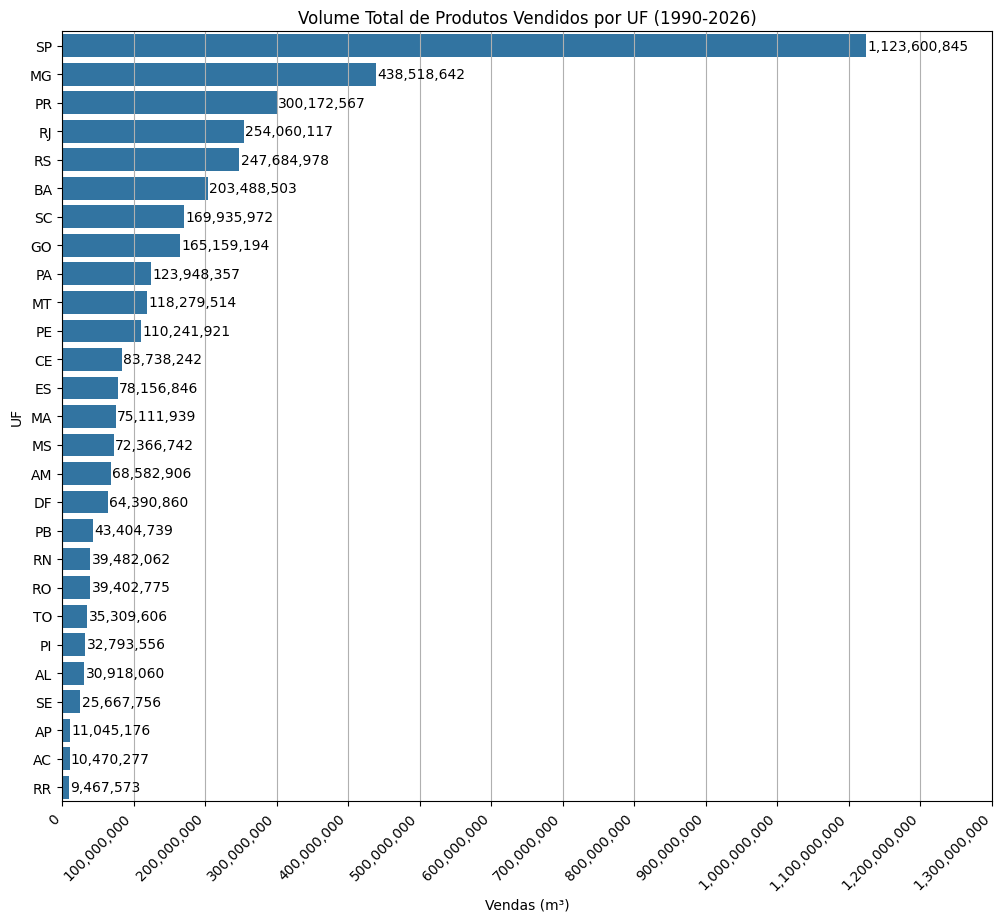

In [7]:
plt.figure(figsize=(12, 10))
# gráfico de barras mostrando as vendas por UF
df_grp = df.groupby(['UF'])['VENDAS'].sum().reset_index().sort_values('VENDAS', ascending=False) # agrupando as vendas por UF
ax = sns.barplot(x='VENDAS', y='UF', data=df_grp) # plot
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=1) # Adição dos valores totais para cada UF estilizado sem notacao cientifica e com separadores de milhar
plt.title('Volume Total de Produtos Vendidos por UF (1990-2026)') # Titulo
plt.ylabel('UF') # label y
plt.xlabel('Vendas (m³)') # label x
plt.xticks(np.arange(0, df_grp['VENDAS'].max()+200000000, 100000000), rotation=45) # aumentando a granularidade do eixo x
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # remocao da notacao cientifica e adicao do separador de milhar no eixo x
ax.set_xticklabels(ax.get_xticklabels(), horizontalalignment='right') # alinhamento dos valores do eixo x a direita
plt.grid(axis='x') # adicao do grid do eixo x
plt.show()

In [8]:
# calculo da razao de vendas em sao paulo em relacao ao todo
df_grp[df_grp['UF']=='SP']['VENDAS'].sum()/df_grp['VENDAS'].sum() # porcentagem de vendas em São Paulo

np.float64(0.28263845709096436)

Aqui notamos que o maior consumidor de derivados de petróleo e biocombustíveis de 1990 a FEV-2026 é São Paulo sendo resposável por 28% das vendas em todo o país.

Agora, o gráfico abaixo contém o volume vendido em cada unidade da federação no período mais recente encontrado no dataset (FEV-2026)

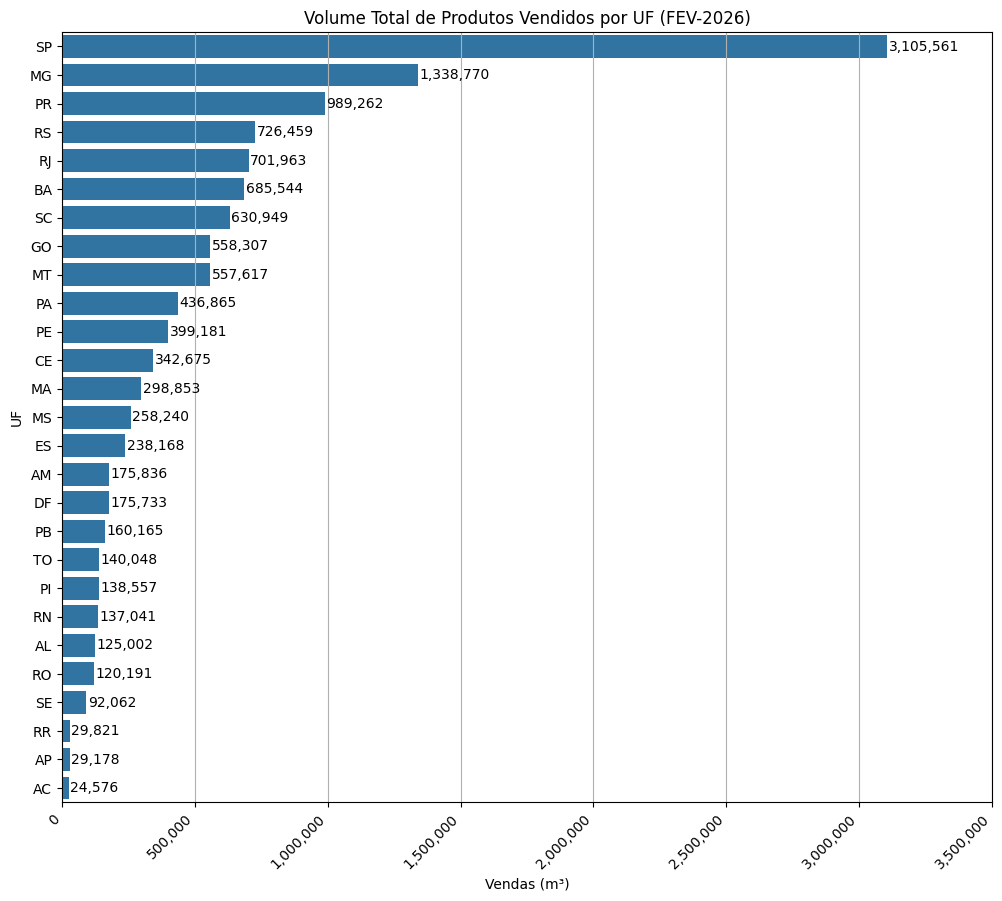

In [9]:
plt.figure(figsize=(12, 10))
# gráfico de barras mostrando o volume total das vendas por UF no ultimo mes registrado no dataset
df_grp =  df[df['DATA'] == '2026-01-01'].groupby(['UF'])['VENDAS'].sum().reset_index().sort_values('VENDAS', ascending=False) # agrupando as vendas por UF
ax = sns.barplot(x='VENDAS', y='UF', data=df_grp) # plot
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=1) # Adição dos valores totais para cada UF estilizado sem notacao cientifica e com separadores de milhar
plt.title('Volume Total de Produtos Vendidos por UF (FEV-2026)') # Titulo
plt.ylabel('UF') # label y
plt.xlabel('Vendas (m³)') # label x
plt.xticks(np.arange(0, df_grp['VENDAS'].max()+500000, 500000), rotation=45) # aumentando a granularidade do eixo x
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # remocao da notacao cientifica e adicao do separador de milhar no eixo x
ax.set_xticklabels(ax.get_xticklabels(), horizontalalignment='right') # alinhamento dos valores do eixo x a direita
plt.grid(axis='x') # adicao do grid do eixo x
plt.show()

E São Paulo continua sendo o maior consumidor de derivados de petróleo e biocombustíveis em Fevereiro de 2026.

### Volume vendido de cada produto
Já quanto ao volume vendido de cada produto, é possível ver no gráfico abaixo este volume em todo o território nacional desde 1990 até FEV-2026

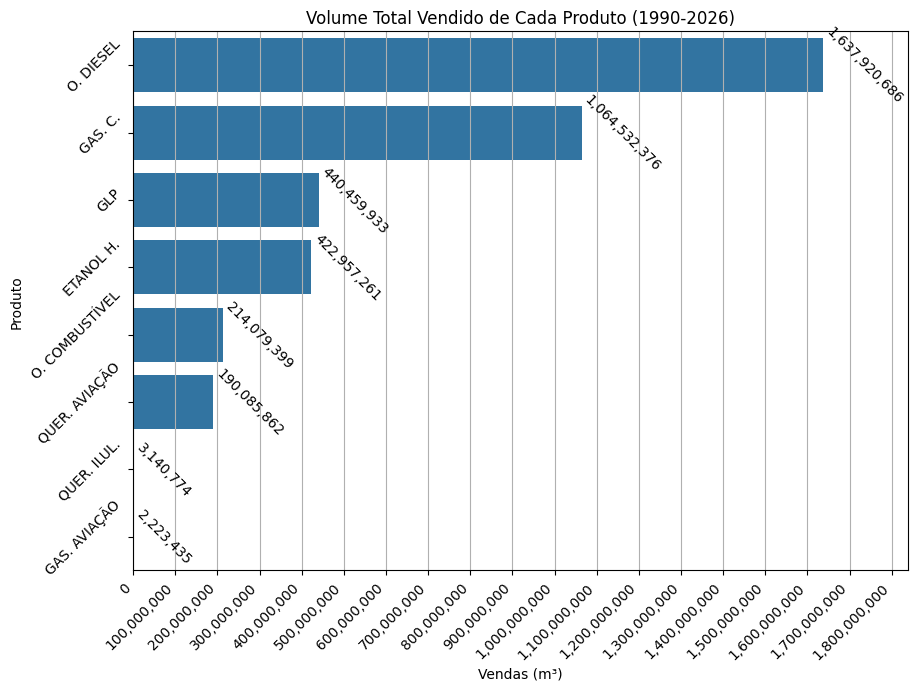

In [10]:
plt.figure(figsize=(10, 7))
df_grp = df.groupby(['PROD'])['VENDAS'].sum().reset_index().sort_values('VENDAS', ascending=False) # agrupando por produto
# gráfico de barras com o volume total vendido de cada produto em todo o territorio nacional
ax = sns.barplot(x='VENDAS', y='PROD', data=df_grp)
ax.bar_label(ax.containers[0], fmt = '{:,.0f}', rotation=-45) # Adição dos valores totais em cada barra para cada UF estilizado sem notacao cientifica e com separadores de milhar
plt.title('Volume Total Vendido de Cada Produto (1990-2026)') # titulo
plt.ylabel('Produto') # label x
plt.xlabel('Vendas (m³)') # label y
plt.ticklabel_format(style='plain', axis='x') # remocao da notacao cientifica no eixo x
plt.xticks(np.arange(0, df_grp['VENDAS'].max()+200000000, 100000000), rotation=45) # aumentando a granularidade do eixo x
ax.set_xlim(left=0, right=df_grp['VENDAS'].max()+201000000) # definindo os limites do eixo x
ax.set_xticklabels(ax.get_xticklabels(), horizontalalignment='right') # mudando o alinhamento dos valores no eixo x
ax.set_yticklabels(ax.get_yticklabels(), horizontalalignment='right', va='center', rotation=45) # mudando o alinhamento dos valores no eixo y e rotacionando de 45 graus
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # remocao da notacao cientifica nos valores totais de cada barra
plt.grid(axis='x') # adicao do grid no eixo x
plt.show()

Já neste gráfico, é possível notar que óleo diesel é o produto que mais foi vendido em todo o território nacional desde 1990.

Mais uma vez, é interessante observar as vendas mais recentes. O gráfico abaixo contém o volume vendido em em todo o território nacional no período mais recente encontrado no dataset (FEV-2026).

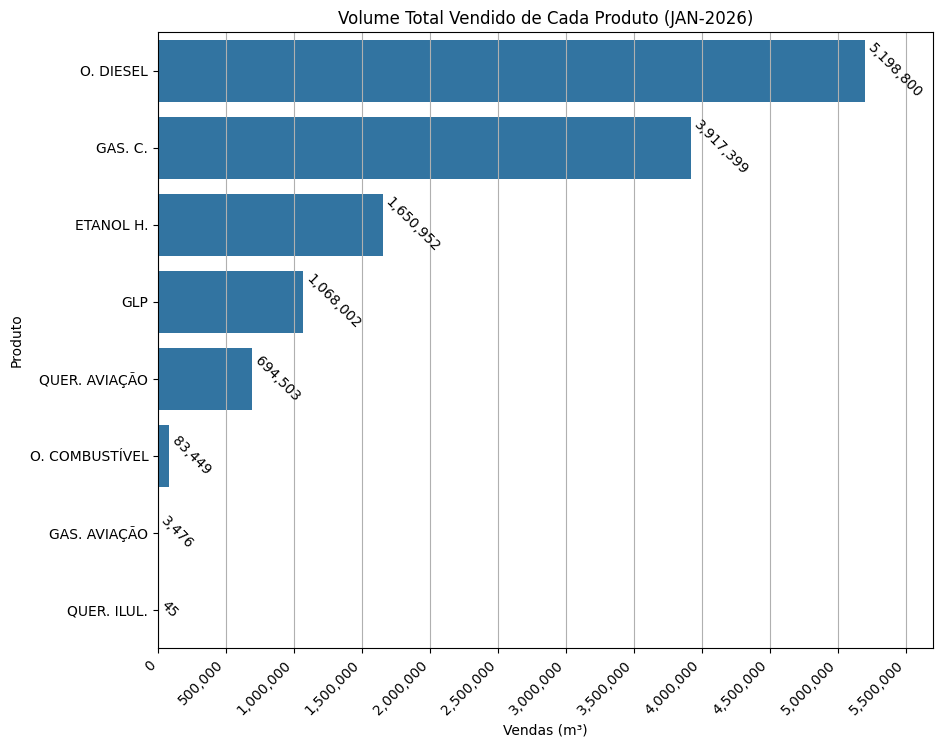

In [11]:
plt.figure(figsize=(10, 8))
df_grp = df[df['DATA'] == '2026-01-01'].groupby(['PROD'])['VENDAS'].sum().reset_index().sort_values('VENDAS', ascending=False) # agrupando por produto
# gráfico de barras com o volume total vendido de cada produto em todo o territorio nacional no mes mais recente do dataset
ax = sns.barplot(x='VENDAS', y='PROD', data=df_grp)
ax.bar_label(ax.containers[0], fmt = '{:,.0f}', rotation=-45) # Adição dos valores totais em cada barra para cada UF estilizado sem notacao cientifica e com separadores de milhar
plt.title('Volume Total Vendido de Cada Produto (JAN-2026)') # titulo
plt.ylabel('Produto') # label y
plt.xlabel('Vendas (m³)') # label x
ax.set_xticklabels(ax.get_xticklabels(), horizontalalignment='right') # remocao da notacao cientifica no eixo x
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # remocao da notacao cientifica nos valores totais de cada barra
plt.xticks(np.arange(0, df_grp['VENDAS'].max()+500000, 500000), rotation=45) # aumentando a granularidade do eixo x e rotacionando em 45 graus
ax.set_xlim(left=0, right=df_grp['VENDAS'].max()+500000) # definindo os limites do eixo x
plt.grid(axis='x') # adicionando o grid do eixo x
plt.show()

E o óleo diesel continua sendo o produto mais foi vendido em todo o território nacional em Fevereiro de 2026.

### Vendas ao Longo do Tempo

Outra visualização importante é a de vendas ao longo do tempo que pode ser vista no próximo gráfico com os valores de vendas de cada produto ao longo do tempo.

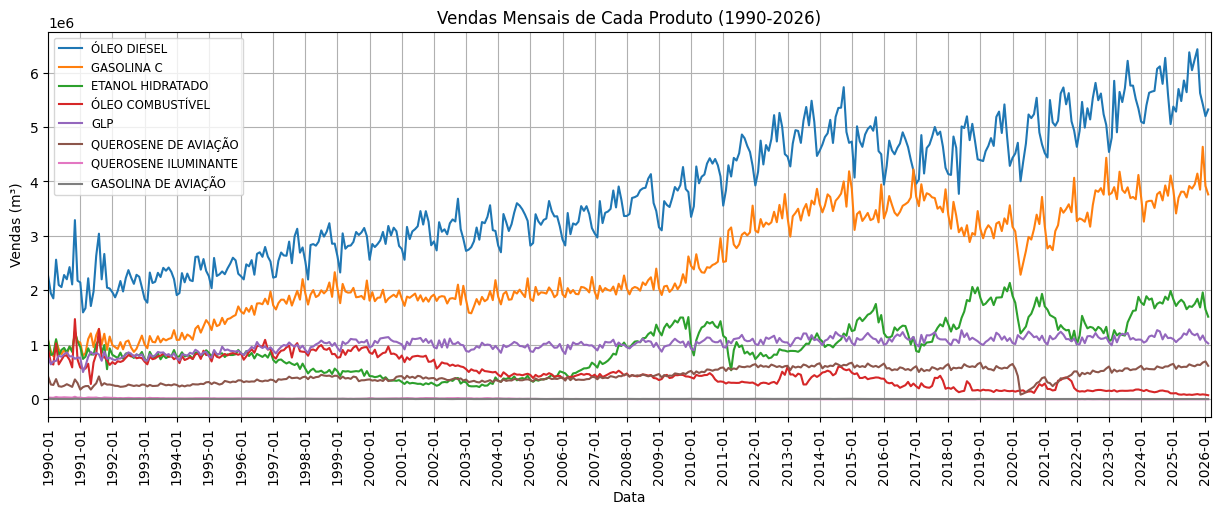

In [12]:
df_grp = df.groupby(['DATA','PRODUTO'])['VENDAS'].sum().reset_index().sort_values('VENDAS', ascending=False) # agrupamento por produto
fig, ax = plt.subplots()
fig.set_size_inches(15, 5)
# loop para filtrar os valores referentes a cada produto
for produto in df_grp['PRODUTO'].unique():
  sns.lineplot(data=df_grp[df_grp['PRODUTO'] == produto], x='DATA', y='VENDAS', label=produto, ax=ax) # plot de cada produto
plt.legend(loc="upper left") # posicionando a legenda no canto superior esquerdo
plt.legend(fontsize='small') # definindo o tamanho da legenda como small
plt.title('Vendas Mensais de Cada Produto (1990-2026)') # titulo
plt.ylabel('Vendas (m³)') # label y
plt.xlabel('Data') # label x
ax.xaxis.set_major_locator(mdates.YearLocator()) # definindo a frequencia do eixo x como anual
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # formatando o eixo x como ano-mes
plt.xticks(rotation=90) # rotacionando os valores do eixo x em 90 graus
ax.set_xlim(left=datetime.date(1990, 1, 1), right=datetime.date(2026, 3, 1))  # definindo o intervalo de tempo do grafico
plt.grid() # adicionando o grid
plt.show()


Neste gráfico é possível notar que em todos os anos o óleo diesel foi o produto mais vendido duranto o ano inteiro. Também é possível perceber visualmente uma sazonalidade anual nas vendas do óleo diesel onde no final e começo dos anos é mais baixa e no meio dos anos é mais alta. Um caso curioso ocorre entre 2020 e 2021 onde as vendas de gasolina comum e etanol hidratado diminuíram devido à pandemia de COVID-19. Por fim, é possível notar visivelmente uma tendência crescente nas vendas de óleo diesel e gasolina comum, pelo menos ao considerar todo o período de 1990 até FEV-2026.



## Estatísticas Descritivas

Antes de analisar as estatísticas descritivas do dataset, vamos adicionar colunas para saber a diferença entre a venda atual e a venda anterior para sabermos se houve um crescimento ou decrescimeto entre elas. Para isso, vamos separar o dataframe por produto. Para esta analise, serão consideradas as vendas em todo o território nacional, sem distinção da unidade da federação.

In [13]:
# declaracao da variavel para os datasets de cada produto
df_vendas_nac = {}

# loop para separar os produtos, a key de cada dataset sera o nome do produto
for produto in df['PRODUTO'].unique():
  df_vendas_nac[f'{produto}'] = df[df['PRODUTO'] == f'{produto}'].sort_values('DATA', ascending=True).groupby(['DATA', 'PRODUTO'])['VENDAS'].sum().reset_index() # criando um df separado para vendas totais de cada produto
  df_vendas_nac[f'{produto}']['VENDAS_LAG_1'] =  df_vendas_nac[f'{produto}']['VENDAS'].shift(1) # criando coluna com o valor anterior
  df_vendas_nac[f'{produto}']['VENDAS_LAG_12'] =  df_vendas_nac[f'{produto}']['VENDAS'].shift(12) # criando coluna com o valor do ano passado
  df_vendas_nac[f'{produto}']['VENDAS_DIF_1'] =  df_vendas_nac[f'{produto}']['VENDAS'].diff(1) # criando coluna com a diferenca em relação ao ultimo mes
  df_vendas_nac[f'{produto}']['VENDAS_DIF_12'] =  df_vendas_nac[f'{produto}']['VENDAS'].diff(12) # criando coluna com a diferenca em relação ao ultimo ano
  df_vendas_nac[f'{produto}']['VENDAS_MM'] =  df_vendas_nac[f'{produto}']['VENDAS'].rolling(window=12).mean() # criando a coluna com a com a media movel dos ultimos 12 meses

df_vendas_nac['ETANOL HIDRATADO'] # exemplo para visualizacao

,DATA,PRODUTO,VENDAS,VENDAS_LAG_1,VENDAS_LAG_12,VENDAS_DIF_1,VENDAS_DIF_12,VENDAS_MM
0,1990-01-01,ETANOL HIDRATADO,1084613.849,NaN,NaN,NaN,NaN,NaN
1,1990-02-01,ETANOL HIDRATADO,811658.259,1084613.849,NaN,-272955.590,NaN,NaN
2,1990-03-01,ETANOL HIDRATADO,832448.150,811658.259,NaN,20789.891,NaN,NaN
3,1990-04-01,ETANOL HIDRATADO,1103345.960,832448.150,NaN,270897.810,NaN,NaN
4,1990-05-01,ETANOL HIDRATADO,795364.735,1103345.960,NaN,-307981.225,NaN,NaN
...,...,...,...,...,...,...,...,...
429,2025-10-01,ETANOL HIDRATADO,1844931.992,1752385.604,1884260.318,92546.388,-39328.326,1.783722e+06
430,2025-11-01,ETANOL HIDRATADO,1685964.155,1844931.992,1825826.759,-158967.837,-139862.604,1.772067e+06
431,2025-12-01,ETANOL HIDRATADO,1962161.342,1685964.155,1988460.246,276197.187,-26298.904,1.769875e+06
432,2026-01-01,ETANOL HIDRATADO,1650951.551,1962161.342,1835715.865,-311209.791,-184764.314,1.754478e+06


Assim, podemos analisar também os crecimentos e crecimentos ao longo do tempo. Agora, olhando para as vendas por produto temos:

In [14]:
# estatísticas descritivas básicas do dataset
pd.set_option('display.float_format', lambda x: '%.0f' % x)
# loop para descrever o dataset de cada produto
for produto in df['PRODUTO'].unique():
  print(f'{produto}\n', df_vendas_nac[f'{produto}'][['PRODUTO','VENDAS', 'VENDAS_DIF_1', 'VENDAS_DIF_12']].describe())
  print('\n')

ETANOL HIDRATADO
        VENDAS  VENDAS_DIF_1  VENDAS_DIF_12
count     434           433            422
mean   974556           997          22221
std    470781        113358         245801
min    224405       -529963        -697892
25%    571882        -51949        -117343
50%    885604          5952           4536
75%   1313548         58715         145871
max   2137636        383859         716432


GLP
        VENDAS  VENDAS_DIF_1  VENDAS_DIF_12
count     434           433            422
mean  1014885           580          11082
std    128907         71807          47986
min    499015       -261690        -196405
25%    944651        -48344         -19326
50%   1037329         -2097          14004
75%   1105044         46107          40928
max   1283420        234323         219008


GASOLINA DE AVIAÇÃO
        VENDAS  VENDAS_DIF_1  VENDAS_DIF_12
count     434           433            422
mean     5123           -21           -123
std      1419          1021            998
min   

Olhando para estas estatísticas, percebe-se que em média o óleo diesel e a gasolina comum são os produtos mais vendidos ao longo de todo o ano e possuem uma tendência crescente ao olhar a média das diferenças de vendas. Abaixo estão os gráficos destas médias para uma melhor visualização da evolução destas medidas.

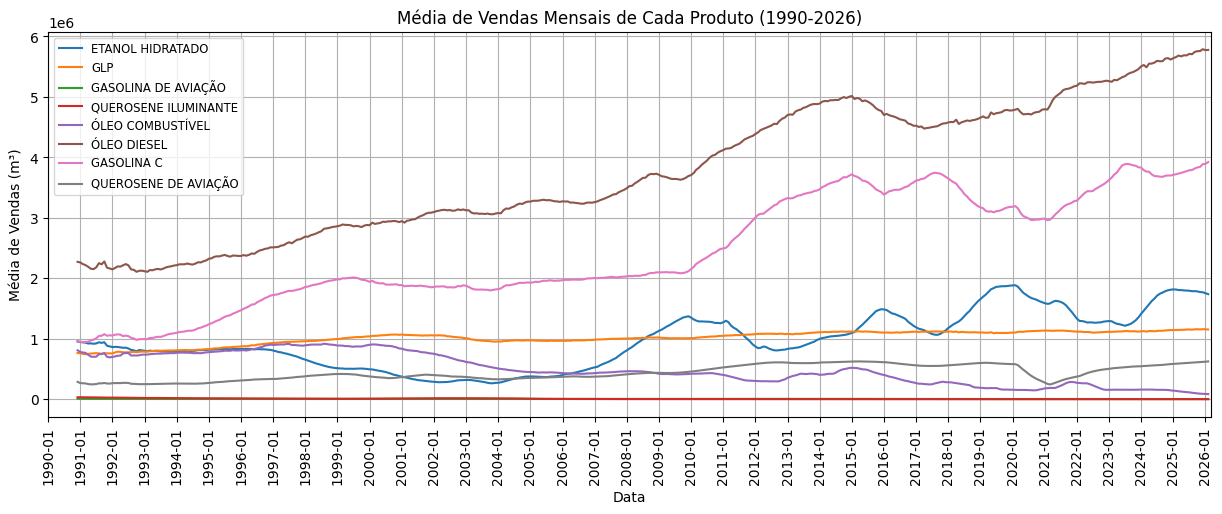

In [15]:
fig, ax = plt.subplots()
fig.set_size_inches(15, 5)
for produto in df['PRODUTO'].unique():
  sns.lineplot(data=df_vendas_nac[f'{produto}'], x='DATA', y='VENDAS_MM', label=produto, ax=ax) # plot da media de cada produto
plt.legend(loc="upper left") # posicionando a legenda no canto superior esquerdo
plt.legend(fontsize='small') # definindo o tamanho da fonte da legenda como smalll
plt.title('Média de Vendas Mensais de Cada Produto (1990-2026)') # titulo
plt.ylabel('Média de Vendas (m³)') # label y
plt.xlabel('Data') # label x
ax.xaxis.set_major_locator(mdates.YearLocator()) # definindo a frequencia do eixo x como anual
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # formatando o eixo x como ano-mes
plt.xticks(rotation=90) # rotacionando as datas em 90 graus
ax.set_xlim(left=datetime.date(1990, 1, 1), right=datetime.date(2026, 3, 1))  # definindo o intervalo de tempo do grafico
plt.grid() # adicionando o grid
plt.show()

Com o gráfico das médias móveis anuais é mais fácil ver como as vendas de cada produto se desenvolvem ao longo dos anos.

## Correlação

Tendo feito essas análises, pode-se começar a pensar em como esses valores se correlacionam. Se o intuito é prever o próximo mês ou ano de venda, é necessário saber como e o quão forte as vendas passadas influenciam as próximas vendas. Para uma ideia inicial, no gráfico abaixo têm-se o plot das vendas x a venda no mês anterior. A partir daqui, trabalhou-se com os dados de etanol hidratado para simplificar as visualizações e outputs, visto que para os outros produtos basta aplicar os mesmo métodos usando os respequitivos datasets.

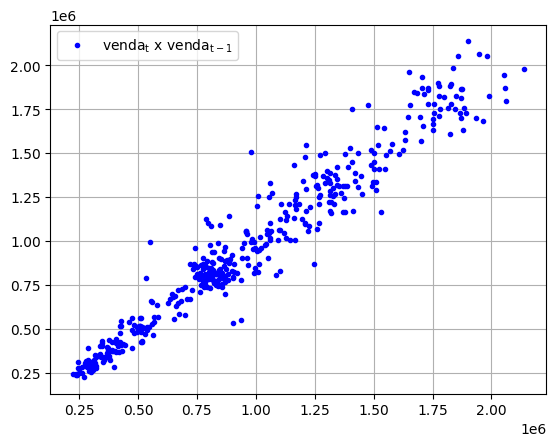

In [16]:
# plot dos valores de vendas x as vendas anteriores
plt.plot( df_vendas_nac['ETANOL HIDRATADO']['VENDAS'], df_vendas_nac['ETANOL HIDRATADO']['VENDAS_LAG_1'], 'b.', label='$\mathregular{venda_t~x~venda_{t-1}}$')
plt.legend(loc="upper left") # posicionando a legenda no canto superior esquerdo
plt.grid() # adicionando o grid

plt.show()

Neste gráfico, pode se notar que existe alguma relação entre o valor anterior e o valor atual, visto que quanto maior o valor anterior, maior o valor atual. Isso expressa uma correlação positiva.

Mas, se o valor anterior possui correlação com o valor atual, e quanto a dois valores anteriores, ou três ou até mesmo o do ano passado no mesmo período? Para responder essas perguntas foi plotadoo gráfico de autocorrelação, que pode ser visto no gráfico a seguir.

In [17]:
from statsmodels.graphics.tsaplots import plot_acf

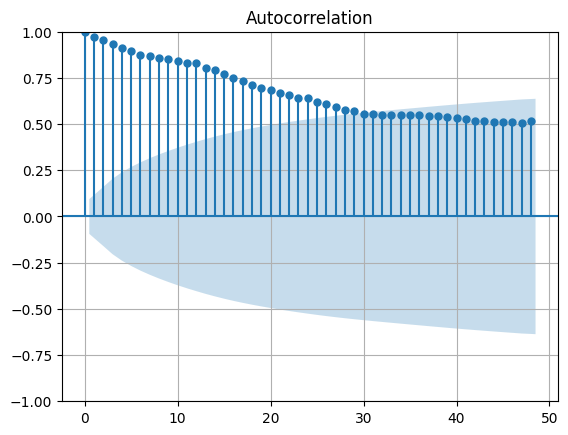

In [18]:
plot_acf(df_vendas_nac['ETANOL HIDRATADO']['VENDAS'], lags = 48) # grafico de autocorrelacao dos ultimos 48 meses
plt.grid() # adicao do grid

plt.show()

Olhando o gráfico, podemos dizer que é insteressante considerar pelo menos os 12 últimos valores, ou seja, 1 ano de dados.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [19]:
# Separacao teste (ultimo ano) e treino.
n = len(df_vendas_nac['ETANOL HIDRATADO']['VENDAS']) # tamanho do dataframe do produto
nteste = 24 # definindo o teste como dois anos
ntreino = n - nteste # o resto como treino

treino, teste = df_vendas_nac['ETANOL HIDRATADO'][['DATA', 'VENDAS']][0: ntreino], df_vendas_nac['ETANOL HIDRATADO'][['DATA', 'VENDAS']][ntreino:] # atribuindo os valores de treino e teste

In [20]:
print(f"Dimensões de treino: {treino.shape}")
print(f"Dimensões de teste: {teste.shape}")

Dimensões de treino: (410, 2)
Dimensões de teste: (24, 2)


# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

**É possível prever as vendas de derivados de petróleo e biocombustíveis?**

Sim, porém de forma limitada. Sabendo que existe uma sazonalidade nas vendas e que há uma autocorrelação nos dados, é possível gerar um modelo de regressão para prever as vendas futuras. Porém, como dito no inicio deste trabalho, existe uma limitação devido a dependencia a outros fatores politicos e ambientais.

## Hipótese 2

**Qual região consome mais ou menos de determinado produto?**

Com os gráficos de barras agrupando corretamente os dados é fácil determinar qual região consome determinada quantidade de cada produto. Isso traz uma vantagem clara na decisão estratégica de como, onde e no que investir, por exemplo.

## Hipótese 3

**O quão estável é o setor de derivados de petróleo e biocombustíveis?**

Ao analizar as estatísticas decritivas e gráficos de vendas e médias de vendas ao longo do tempo percebe-se como as vendas de cada produto se comporta ao longo dos anos. Ficou claro que para os produtos óleo diesel e gasolina comum há um crescimento nas vendas ao longo dos anos.

# Conclusão

A análise e pré-processamento do dataset vendas de derivados de petróleo e biocombustíveis dão insights valiosíssimos para o setor. Pode-se observar o desenvolvimento das vendas ao longo dos anos o que ajuda a defenir onde e em que investir. Não só isso, como se nota padrões que podem ajudar a preparar estoque e linhas de distribuição mais eficientes. E quem sabe as informações que se pode obter com a integração desta análise com outras análises como o de produção, clima e eventos.